# 1. Prepare data

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score

In [22]:
df = pd.read_excel('../data/Churn_Model_Ready.xlsx')
X = df.drop(columns=['ChurnStatus'])
y = df['ChurnStatus']

In [23]:
X.dtypes

Age                   float64
TotalSpend            float64
AvgSpend              float64
NumTransactions       float64
DaysSinceLastTx       float64
NumInteractions       float64
NumComplaints         float64
NumUnresolved         float64
DaysSinceLastLogin    float64
LoginFrequency        float64
AvgSpend_clean        float64
HasServiceRecord      float64
Gender_enc            float64
Income_enc            float64
MS_Married            float64
MS_Single             float64
MS_Widowed            float64
SU_Online Banking     float64
SU_Website            float64
FC_Clothing           float64
FC_Electronics        float64
FC_Furniture          float64
FC_Groceries          float64
AgeGroup_enc          float64
SpendPerTx            float64
ComplaintRate         float64
IsHighRisk            float64
dtype: object

In [24]:
y.dtypes

dtype('int64')

In [25]:
# Train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [26]:
# Apply SMOTE 
smote=SMOTE(random_state=42)
X_train_res,y_train_res = smote.fit_resample(X_train, y_train)

# 2. Model Building

In [27]:
# 1. Logistic Regression (baseline)
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_res,y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [28]:
# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators = 100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_res,y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
# 3. XGBoost
xgb_model = xgb.XGBClassifier(
    scale_pos_weight = 796/204,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [32]:
for name, model in [('Logistic Regression', lr),
                    ('Random Forest', rf),
                    ('XGBoost', xgb_model)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*80}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.50      0.60       159
           1       0.15      0.34      0.21        41

    accuracy                           0.47       200
   macro avg       0.45      0.42      0.41       200
weighted avg       0.63      0.47      0.52       200

AUC-ROC: 0.419

Model: Random Forest
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       159
           1       0.33      0.12      0.18        41

    accuracy                           0.77       200
   macro avg       0.57      0.53      0.52       200
weighted avg       0.71      0.77      0.73       200

AUC-ROC: 0.502

Model: XGBoost
              precision    recall  f1-score   support

           0       0.80      0.63      0.70       159
           1       0.21      0.39      0.28        41

    accuracy                           0.58       200
   macro avg       0.51      0.5

### Random Forest is our best model because of the weak individual correlations

# 3. Evaluation

In [41]:
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import matplotlib.pyplot as plt

In [34]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1 ]

In [38]:
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.81      0.94      0.87       159
     Churned       0.33      0.12      0.18        41

    accuracy                           0.77       200
   macro avg       0.57      0.53      0.52       200
weighted avg       0.71      0.77      0.73       200



In [36]:
# AUC-ROC
print(f"AUC-ROC: {roc_auc_score(y_test,y_prob):.3f}")

AUC-ROC: 0.502


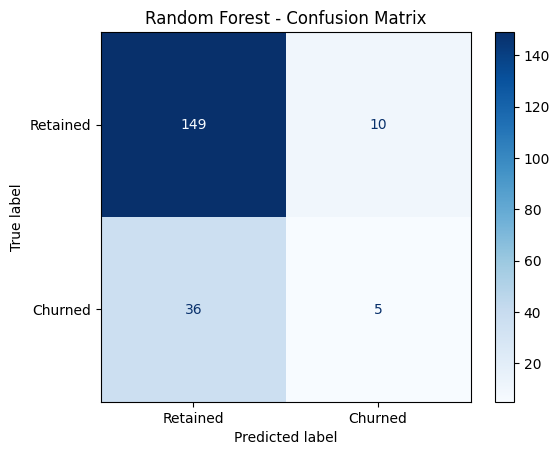

In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

# 4. Hyperparameter Tuning

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100,500),
    'max_depth': randint(3,10),
    'min_samples_split': randint(2,20)
}

rand = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced'),
    param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
rand.fit(X_train_res,y_train_res)
print(rand.best_params_)

{'max_depth': 9, 'min_samples_split': 4, 'n_estimators': 305}


In [46]:
best_rf = RandomForestClassifier(
    max_depth=9,
    min_samples_split=4,
    n_estimators=305,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_train_res,y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",305
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [47]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

In [48]:
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

    Retained       0.80      0.92      0.86       159
     Churned       0.28      0.12      0.17        41

    accuracy                           0.76       200
   macro avg       0.54      0.52      0.51       200
weighted avg       0.69      0.76      0.72       200

AUC-ROC: 0.471


In [49]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_rf, X, y, cv=skf, scoring='roc_auc')

print(f"CV AUC scores: {cv_scores.round(3)}")
print(f"Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV AUC scores: [0.459 0.514 0.674 0.508 0.616]
Mean AUC: 0.554 (+/- 0.079)


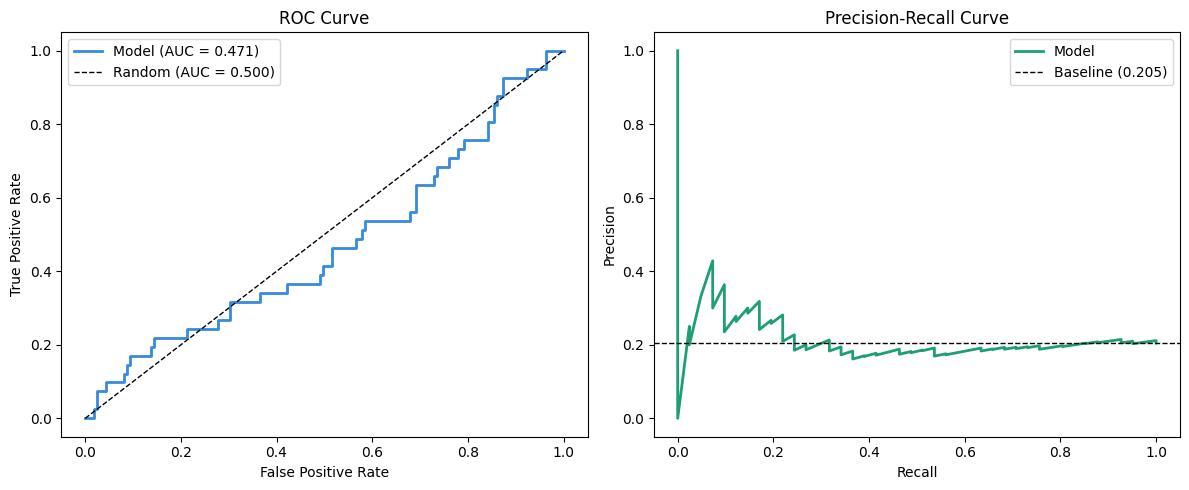

In [50]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── ROC Curve ────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

axes[0].plot(fpr, tpr, color='#378ADD', lw=2, label=f'Model (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# ── Precision-Recall Curve ───────────────────────────────────
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
baseline = y_test.mean()   # churn rate = 0.204

axes[1].plot(recall, precision, color='#1D9E75', lw=2, label='Model')
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Feature Importance and SHAP Values

In [52]:
# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

In [53]:
importances

DaysSinceLastLogin    0.070137
LoginFrequency        0.066817
TotalSpend            0.066700
DaysSinceLastTx       0.065584
Age                   0.064341
Income_enc            0.059829
AgeGroup_enc          0.056300
SpendPerTx            0.054467
AvgSpend              0.052824
AvgSpend_clean        0.051488
dtype: float64

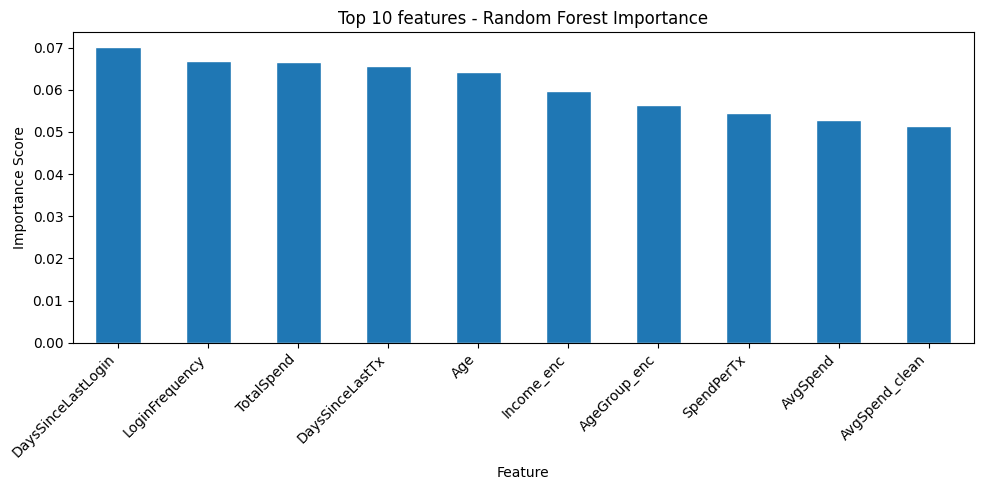

In [57]:
importances.plot(kind='bar', edgecolor='white', figsize=(10,5))
plt.title('Top 10 features - Random Forest Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sv shape: (200, 27)
X_test shape: (200, 27)


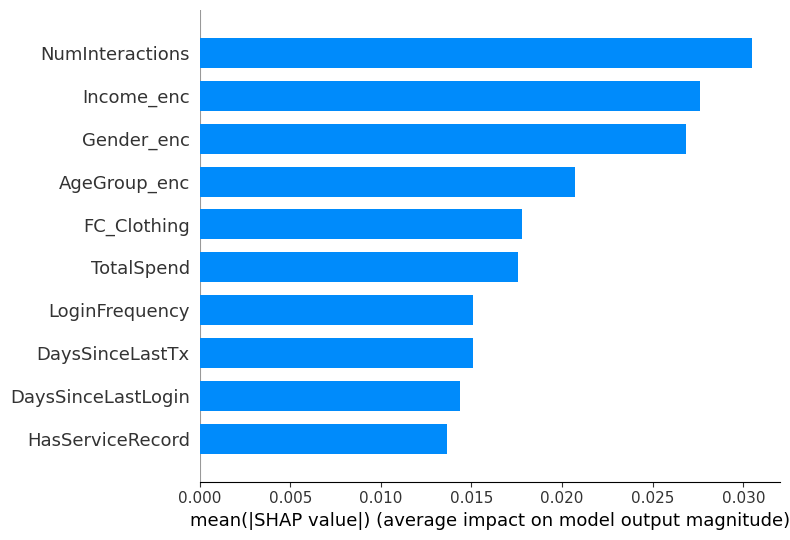

In [75]:
import shap
import numpy as np

explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Handle all SHAP versions
if isinstance(shap_values, list):
    sv = shap_values[1]                  # old: list of arrays
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]           # new: 3D array
else:
    sv = shap_values                     # single output model

print("sv shape:", sv.shape)            # should be (200, 27)
print("X_test shape:", X_test.shape)   # should be (200, 27)

shap.summary_plot(sv, X_test, plot_type='bar', max_display=10)